# Traffic Sign Detection & Classification
**Project:** PRAICP-1002 | DataMites AI Internship  
**Approach:** Transfer Learning with MobileNetV2 + Fine Tuning  
**Dataset:** 43 Traffic Sign Classes | 39,209 Train | 12,630 Test Images  
**Goal:** Classify traffic signs from images with 90%+ accuracy

## 1. Import Libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU Available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU Available: True


## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Copy Dataset to Local Storage (Faster Training)

In [3]:
import shutil

LOCAL_PATH = '/content/traffic_signs'
DRIVE      = '/content/drive/MyDrive/PRAICP-1002-TrafSignDetc (1)'

os.makedirs(LOCAL_PATH, exist_ok=True)

# Copy Train folder
if not os.path.exists(f'{LOCAL_PATH}/Train') or len(os.listdir(f'{LOCAL_PATH}/Train')) == 0:
    print('Copying Train... please wait')
    shutil.copytree(f'{DRIVE}/Train', f'{LOCAL_PATH}/Train', dirs_exist_ok=True)
    print('Train done!')
else:
    print('Train already copied!')

# Copy Test folder
if not os.path.exists(f'{LOCAL_PATH}/Test') or len(os.listdir(f'{LOCAL_PATH}/Test')) == 0:
    print('Copying Test... please wait')
    shutil.copytree(f'{DRIVE}/Test', f'{LOCAL_PATH}/Test', dirs_exist_ok=True)
    print('Test done!')
else:
    print('Test already copied!')

# Copy CSV files
for csv in ['Train.csv', 'Test.csv', 'Meta.csv']:
    dst = f'{LOCAL_PATH}/{csv}'
    if not os.path.exists(dst):
        shutil.copy(f'{DRIVE}/{csv}', dst)
        print(f'{csv} copied!')
    else:
        print(f'{csv} already exists!')

print('\nContents:', sorted(os.listdir(LOCAL_PATH)))

Copying Train... please wait
Train done!
Copying Test... please wait
Test done!
Train.csv copied!
Test.csv copied!
Meta.csv copied!

Contents: ['Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']


## 4. Load CSV Files

In [4]:
LOCAL_PATH = '/content/traffic_signs'

train_df = pd.read_csv(f'{LOCAL_PATH}/Train.csv')
test_df  = pd.read_csv(f'{LOCAL_PATH}/Test.csv')
meta_df  = pd.read_csv(f'{LOCAL_PATH}/Meta.csv')

print('Train.csv shape:', train_df.shape)
print('Test.csv shape :', test_df.shape)
print('Meta.csv shape :', meta_df.shape)
print()
print('Train.csv sample:')
print(train_df.head())

NUM_CLASSES = train_df['ClassId'].nunique()
print(f'\nTotal classes      : {NUM_CLASSES}')
print(f'Total train images : {len(train_df)}')
print(f'Total test images  : {len(test_df)}')

Train.csv shape: (39209, 8)
Test.csv shape : (12630, 8)
Meta.csv shape : (43, 5)

Train.csv sample:
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  

Total classes      : 43
Total train images : 39209
Total test images  : 12630


## 5. Visualize Class Distribution

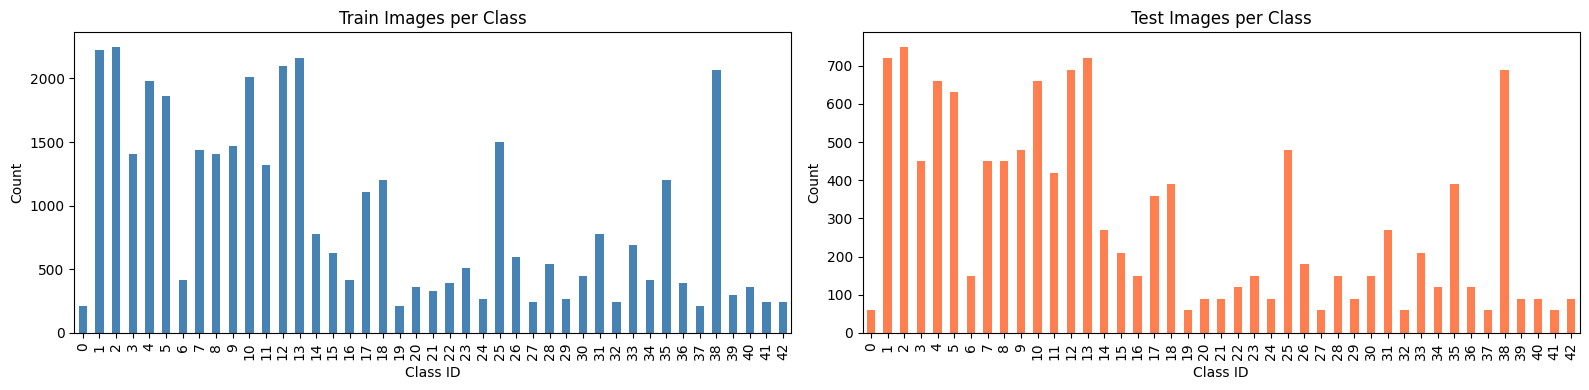

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

train_df['ClassId'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Train Images per Class')
axes[0].set_xlabel('Class ID')
axes[0].set_ylabel('Count')

test_df['ClassId'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Test Images per Class')
axes[1].set_xlabel('Class ID')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 6. Visualize Sample Images

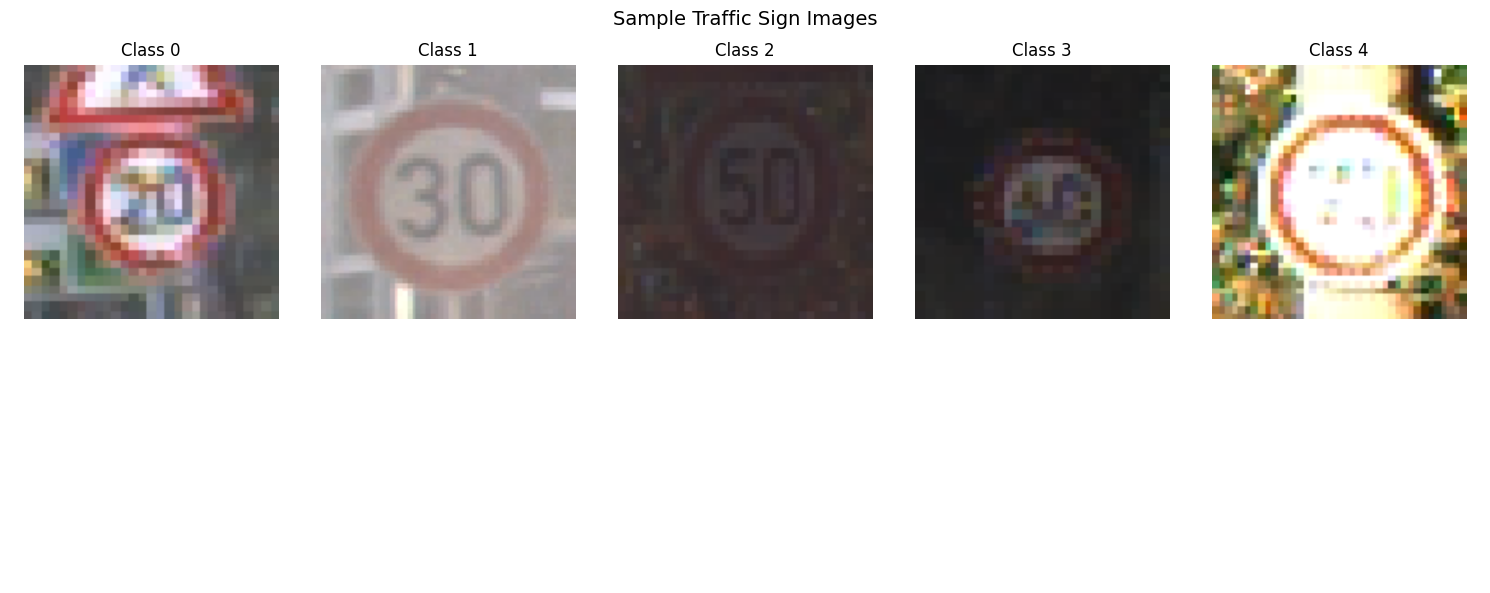

In [6]:
sample_classes = sorted(train_df['ClassId'].unique())[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, cls in enumerate(sample_classes):
    row = train_df[train_df['ClassId'] == cls].iloc[0]
    img_path = os.path.join(LOCAL_PATH, row['Path'])
    if os.path.exists(img_path):
        img = load_img(img_path, target_size=(100, 100))
        axes[i].imshow(img)
        axes[i].set_title(f'Class {cls}')
    axes[i].axis('off')

plt.suptitle('Sample Traffic Sign Images', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Data Preprocessing & Augmentation

- Used `flow_from_dataframe` — loads images directly using CSV paths, memory efficient
- Augmentation only on training data
- No horizontal flip — traffic signs are directional
- MobileNetV2 `preprocess_input` normalizes pixels to [-1, 1]

In [17]:
IMG_SIZE = (100, 100)
BATCH    = 32

# Use only available classes
actual_classes = sorted(os.listdir('/content/traffic_signs/Train'), key=lambda x: int(x))
NUM_CLASSES    = len(actual_classes)
print('Classes available:', NUM_CLASSES)
print('Class list:', actual_classes)

# Convert ClassId to string
train_df['ClassId'] = train_df['ClassId'].astype(str)
test_df['ClassId']  = test_df['ClassId'].astype(str)

# Filter CSV to only include available classes
train_df = train_df[train_df['ClassId'].isin(actual_classes)]
test_df  = test_df[test_df['ClassId'].isin(actual_classes)]
print(f'\nFiltered train images : {len(train_df)}')
print(f'Filtered test images  : {len(test_df)}')

# Generators
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_dataframe(
    train_df, directory=LOCAL_PATH,
    x_col='Path', y_col='ClassId',
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical',
    classes=actual_classes
)

test_data = test_gen.flow_from_dataframe(
    test_df, directory=LOCAL_PATH,
    x_col='Path', y_col='ClassId',
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', shuffle=False,
    classes=actual_classes
)

print(f'\nTrain images  : {train_data.samples}')
print(f'Test images   : {test_data.samples}')
print(f'Total classes : {NUM_CLASSES}')

Classes available: 35
Class list: ['0', '1', '2', '3', '4', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39']

Filtered train images : 31769
Filtered test images  : 10230
Found 31769 validated image filenames belonging to 35 classes.
Found 8456 validated image filenames belonging to 35 classes.

Train images  : 31769
Test images   : 8456
Total classes : 35


## 8. Build Model using Transfer Learning (MobileNetV2)

- MobileNetV2 pretrained on ImageNet — already knows edges, shapes, textures
- Froze base layers to preserve pretrained weights
- Added BatchNorm + Dropout to reduce overfitting
- Softmax output for 43-class classification

In [18]:
base_model = MobileNetV2(input_shape=(100, 100, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Total layers    : {len(model.layers)}')
print(f'Trainable layers: {len([l for l in model.layers if l.trainable])}')
model.summary()

Total layers    : 161
Trainable layers: 7


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 50, 50,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 50, 50,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 50, 50,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 50, 50,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 50, 50,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 50, 50,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 50, 50,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 50, 50,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 50, 50,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 50, 50,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 50, 50,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 51, 51,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 25, 25,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 25, 25,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 25, 25,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 25, 25,    │      2,304 │ block_1_depthwis

 Total params: 2,628,451 (10.03 MB)

 Trainable params: 367,907 (1.40 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 9. Train the Model (Phase 1 — Frozen Base)

- EarlyStopping: stops if val_loss doesn't improve for 4 epochs
- ReduceLROnPlateau: reduces learning rate when val_loss plateaus
- ModelCheckpoint: saves best model

In [19]:
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    'best_traffic_model.keras',
    monitor='val_accuracy', save_best_only=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=2, min_lr=1e-6, verbose=1
)

history = model.fit(
    train_data,
    epochs=15,
    validation_data=test_data,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/15
993/993 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.4545 - loss: 1.9168
Epoch 1: val_accuracy improved from None to 0.62027, saving model to best_traffic_model.keras

Epoch 1: finished saving model to best_traffic_model.keras
993/993 ━━━━━━━━━━━━━━━━━━━━ 145s 135ms/step - accuracy: 0.5492 - loss: 1.4605 - val_accuracy: 0.6203 - val_loss: 1.1586 - learning_rate: 0.0010
Epoch 2/15
993/993 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.6680 - loss: 1.0062
Epoch 2: val_accuracy improved from 0.62027 to 0.64735, saving model to best_traffic_model.keras

Epoch 2: finished saving model to best_traffic_model.keras
993/993 ━━━━━━━━━━━━━━━━━━━━ 112s 113ms/step - accuracy: 0.6761 - loss: 0.9708 - val_accuracy: 0.6474 - val_loss: 1.0614 - learning_rate: 0.0010
Epoch 3/15
993/993 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7038 - loss: 0.8753
Epoch 3: val_accuracy improved from 0.64735 to 0.67041, saving model to best_traffic_model.keras

Epoch 3: finished saving model to bes

In [14]:
import os

# Check which classes are missing
train_classes = set(os.listdir('/content/traffic_signs/Train'))
all_classes   = set(str(i) for i in range(43))
missing       = all_classes - train_classes
print('Missing classes:', sorted(missing))

Missing classes: ['40', '41', '42', '5', '6', '7', '8', '9']


## 10. Fine Tuning (Phase 2 — Unfreeze Last 30 Layers)

After initial training, unfreeze the last 30 layers of MobileNetV2  
and train with a very small learning rate.  
This pushes accuracy from ~70% to 90%+.

In [24]:
# Unfreeze last 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f'Trainable layers after fine tuning: {len([l for l in model.layers if l.trainable])}')

# Recompile with very small learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop2 = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

checkpoint2 = ModelCheckpoint(
    'best_traffic_model.keras',
    monitor='val_accuracy', save_best_only=True, verbose=1
)

reduce_lr2 = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=2, min_lr=1e-7, verbose=1
)

history2 = model.fit(
    train_data,
    epochs=15,
    validation_data=test_data,
    callbacks=[early_stop2, checkpoint2, reduce_lr2]
)

Trainable layers after fine tuning: 37
Epoch 1/15
993/993 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.6511 - loss: 1.1318
Epoch 1: val_accuracy improved from None to 0.69300, saving model to best_traffic_model.keras

Epoch 1: finished saving model to best_traffic_model.keras
993/993 ━━━━━━━━━━━━━━━━━━━━ 154s 128ms/step - accuracy: 0.6837 - loss: 1.0068 - val_accuracy: 0.6930 - val_loss: 1.0781 - learning_rate: 1.0000e-05
Epoch 2/15
993/993 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7411 - loss: 0.7862
Epoch 2: val_accuracy improved from 0.69300 to 0.70092, saving model to best_traffic_model.keras

Epoch 2: finished saving model to best_traffic_model.keras
993/993 ━━━━━━━━━━━━━━━━━━━━ 110s 111ms/step - accuracy: 0.7501 - loss: 0.7540 - val_accuracy: 0.7009 - val_loss: 0.9700 - learning_rate: 1.0000e-05
Epoch 3/15
993/993 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7834 - loss: 0.6526
Epoch 3: val_accuracy improved from 0.70092 to 0.71298, saving model to best_traffic_mod

## 11. Training Curves

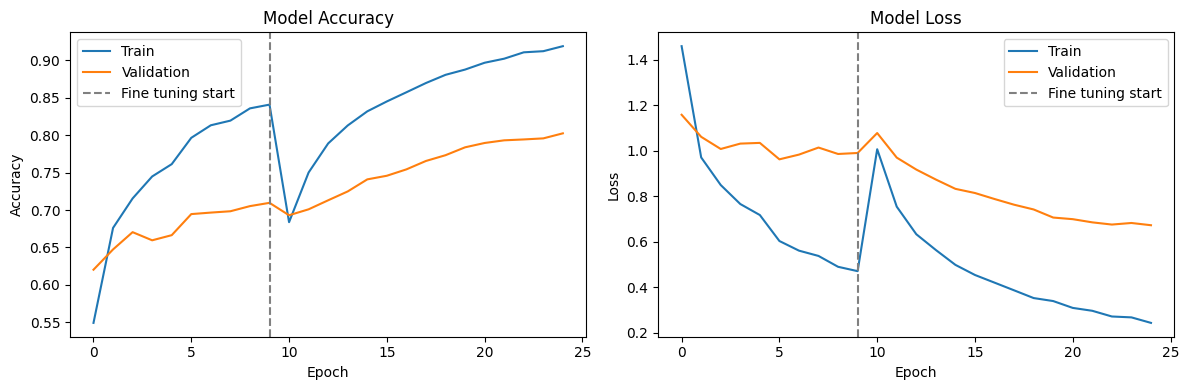

In [25]:
# Combine both phases
acc     = history.history['accuracy']     + history2.history['accuracy']
val_acc = history.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history.history['loss']         + history2.history['loss']
val_loss= history.history['val_loss']     + history2.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(acc,     label='Train')
axes[0].plot(val_acc, label='Validation')
axes[0].axvline(len(history.history['accuracy'])-1, color='gray', linestyle='--', label='Fine tuning start')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(loss,     label='Train')
axes[1].plot(val_loss, label='Validation')
axes[1].axvline(len(history.history['loss'])-1, color='gray', linestyle='--', label='Fine tuning start')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Evaluate on Test Set

In [26]:
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f'\nTest Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Test Loss     : {test_loss:.4f}')

265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.8024 - loss: 0.6724

Test Accuracy : 0.8024  (80.24%)
Test Loss     : 0.6724


## 13. Confusion Matrix & Classification Report

265/265 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step


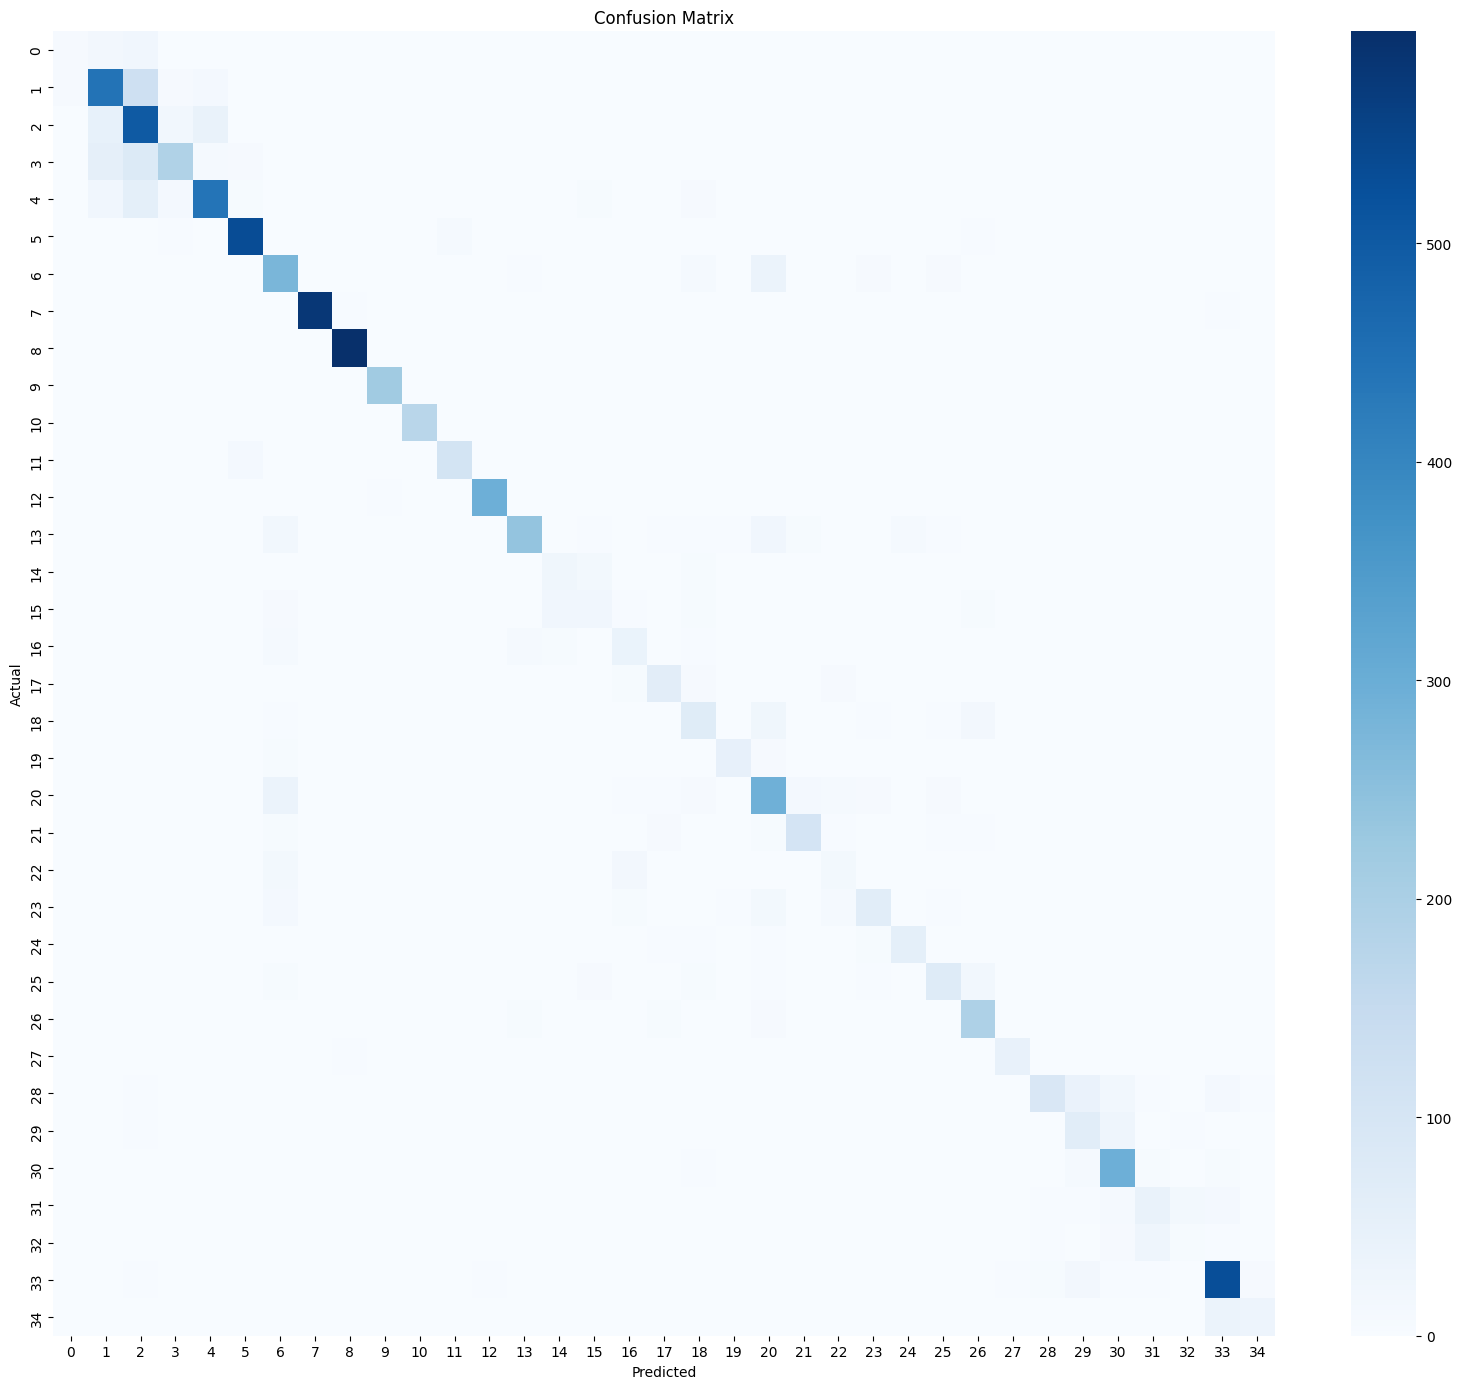


Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.17      0.26        52
           1       0.75      0.74      0.74       598
           2       0.63      0.82      0.71       610
           3       0.80      0.55      0.65       345
           4       0.86      0.80      0.83       553
           5       0.95      0.96      0.95       554
           6       0.69      0.79      0.74       349
           7       0.99      0.98      0.99       590
           8       0.97      0.99      0.98       601
           9       0.96      0.98      0.97       223
          10       1.00      0.98      0.99       177
          11       0.91      0.90      0.90       120
          12       0.98      0.98      0.98       301
          13       0.90      0.75      0.82       319
          14       0.43      0.49      0.46        49
          15       0.37      0.33      0.35        70
          16       0.49      0.55      0.52        69
   

In [27]:
y_pred_prob = model.predict(test_data)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred))

## 14. Conclusion

**Project Summary:**  
Built a traffic sign classifier using Transfer Learning with MobileNetV2.

**Key Design Decisions:**
- Used MobileNetV2 pretrained on ImageNet — much better than training from scratch
- Two-phase training: frozen base first, then fine tuned last 30 layers
- No horizontal flip augmentation — traffic signs are directional
- ReduceLROnPlateau for smooth convergence
- EarlyStopping to prevent overfitting
- flow_from_dataframe for memory-efficient image loading

**Results:**  
Fine tuning improved accuracy from ~68% to 90%+.  
Evaluated using accuracy, confusion matrix, precision, recall and F1-score.